In [1]:
# Importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importing dataset (path relative to this notebook, so it runs from a clone of the repo)

import_df = pd.read_csv('../Excel File/Road_Accident_exc.csv')

In [3]:
# Creating copy of the original dataframe

road_accident_df = import_df.copy()

In [4]:
# Querying for 1st 5 rows

road_accident_df[:5]

,City_Name,Cause_Category,Cause_Subcategory,Outcome_of_Incident,Count_in_mil
0,Agra,Traffic Control,Flashing Signal/Blinker,Greviously Injured,0.0
1,Agra,Traffic Control,Flashing Signal/Blinker,Minor Injury,0.0
2,Agra,Traffic Control,Flashing Signal/Blinker,Persons Killed,0.0
3,Agra,Traffic Control,Flashing Signal/Blinker,Total Injured,0.0
4,Agra,Traffic Control,Flashing Signal/Blinker,Total number of Accidents,0.0


In [5]:
# Querying for missing values

road_accident_df.isnull().sum()

City_Name              0
Cause_Category         0
Cause_Subcategory      0
Outcome_of_Incident    0
Count_in_mil           0
dtype: int64

In [6]:
# Summary of the dataset

road_accident_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9550 entries, 0 to 9549
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   City_Name            9550 non-null   object 
 1   Cause_Category       9550 non-null   object 
 2   Cause_Subcategory    9550 non-null   object 
 3   Outcome_of_Incident  9550 non-null   object 
 4   Count_in_mil         9550 non-null   float64
dtypes: float64(1), object(4)
memory usage: 373.2+ KB


In [7]:
# Analysing total number of rows and columns

road_accident_df.shape

(9550, 5)

In [8]:
# Checking for duplicate values

road_accident_df[road_accident_df.duplicated()]

,City_Name,Cause_Category,Cause_Subcategory,Outcome_of_Incident,Count_in_mil


* There is no duplicate values.

In [9]:
# Statistical summary

road_accident_df.describe(include = "all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
City_Name,9550,50,Agra,191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cause_Category,9550,6,Road Features,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cause_Subcategory,9550,35,Others,1450,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outcome_of_Incident,9550,5,Greviously Injured,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count_in_mil,9550.0,NaN,NaN,NaN,103.595079,275.1522,0.0,0.0,12.0,70.0,3148.0


In [10]:
# Querying total number of unique cities

road_accident_df['City_Name'].unique()

array(['Agra', 'Ahmedabad', 'Allahabad(Prayagraj)', 'Amritsar',
       'Asansol Durgapur', 'Aurangabad', 'Bengaluru', 'Bhopal',
       'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Dhanbad',
       'Faridabad', 'Ghaziabad', 'Gwalior', 'Hyderabad', 'Indore',
       'Jabalpur', 'Jaipur', 'Jamshedpur', 'Jodhpur', 'Kannur', 'Kanpur',
       'Khozikode', 'Kochi', 'Kolkata', 'Kollam', 'Kota', 'Lucknow',
       'Ludhiana', 'Madurai', 'Mallapuram', 'Meerut', 'Mumbai', 'Nagpur',
       'Nashik', 'Patna', 'Pune', 'Raipur', 'Rajkot', 'Srinagar', 'Surat',
       'Thiruvanthapuram', 'Thrissur', 'Tiruchirapalli', 'Vadodra',
       'Varanasi', 'Vijaywada city', 'Vizaq'], dtype=object)

* These are some cities based on which further analysis has been done.

In [11]:
# Querying the top 6 most frequent Cause_Category

road_accident_df['Cause_Category'].value_counts()

Cause_Category
Road Features               2000
Impacting Vehicle/Object    1800
Junction                    1500
Traffic Control             1500
Traffic Violation           1500
Weather                     1250
Name: count, dtype: int64

* These are row counts, not accidents. They differ only because the categories have different numbers of subcategories (Road Features has 8, Weather 5), and Impacting Vehicle/Object has no 'Total Injured' rows.

In [12]:
# Checking the grain: total accidents in each Cause_Category

accidents_only = road_accident_df[road_accident_df['Outcome_of_Incident'] == 'Total number of Accidents']
accidents_only.groupby('Cause_Category')['Count_in_mil'].sum()

Cause_Category
Impacting Vehicle/Object    58736.0
Junction                    58736.0
Road Features               58736.0
Traffic Control             58736.0
Traffic Violation           58736.0
Weather                     58736.0
Name: Count_in_mil, dtype: float64

* Every category adds up to the same 58,736 accidents. The 6 categories are 6 ways of splitting the same accidents, so adding up every row counts each accident 6 times, and it also mixes accidents with people killed or injured.
* From here on, every total is computed inside one category (Traffic Violation) and one outcome at a time.

In [13]:
# Working from one category: national totals for each outcome

one_category = road_accident_df[road_accident_df['Cause_Category'] == 'Traffic Violation']
one_category.groupby('Outcome_of_Incident')['Count_in_mil'].sum()

Outcome_of_Incident
Greviously Injured           20532.0
Minor Injury                 29983.0
Persons Killed               13542.0
Total Injured                50515.0
Total number of Accidents    58736.0
Name: Count_in_mil, dtype: float64

* 58,736 accidents killed 13,542 people and injured 50,515: about 23 deaths per 100 accidents.
* 'Total Injured' is the sum of the two injury rows, so it is never added to them.

In [14]:
# Querying for data where persons got killed

road_accident_df[road_accident_df['Outcome_of_Incident'] == 'Persons Killed']

,City_Name,Cause_Category,Cause_Subcategory,Outcome_of_Incident,Count_in_mil
2,Agra,Traffic Control,Flashing Signal/Blinker,Persons Killed,0.0
7,Agra,Traffic Control,Others,Persons Killed,373.0
12,Agra,Traffic Control,Police Controlled,Persons Killed,0.0
17,Agra,Traffic Control,Stop Sign,Persons Killed,0.0
22,Agra,Traffic Control,Traffic Light Signal,Persons Killed,18.0
...,...,...,...,...,...
9527,Vizaq,Weather,Foggy and Misty,Persons Killed,7.0
9532,Vizaq,Weather,Hail/Sleet,Persons Killed,0.0
9537,Vizaq,Weather,Others,Persons Killed,68.0
9542,Vizaq,Weather,Rainy,Persons Killed,4.0


In [15]:
# Querying for total accidents per city

accidents_city = one_category[one_category['Outcome_of_Incident'] == 'Total number of Accidents'].groupby('City_Name')\
                                .agg(Total_Accidents = ('Count_in_mil','sum')).sort_values(by = 'Total_Accidents',ascending = False)
accidents_city[:10]

,Total_Accidents
City_Name,
Chennai,4389.0
Delhi,4178.0
Bengaluru,3233.0
Jabalpur,3226.0
Indore,3036.0
Bhopal,2295.0
Hyderabad,2064.0
Jaipur,1940.0
Mumbai,1812.0


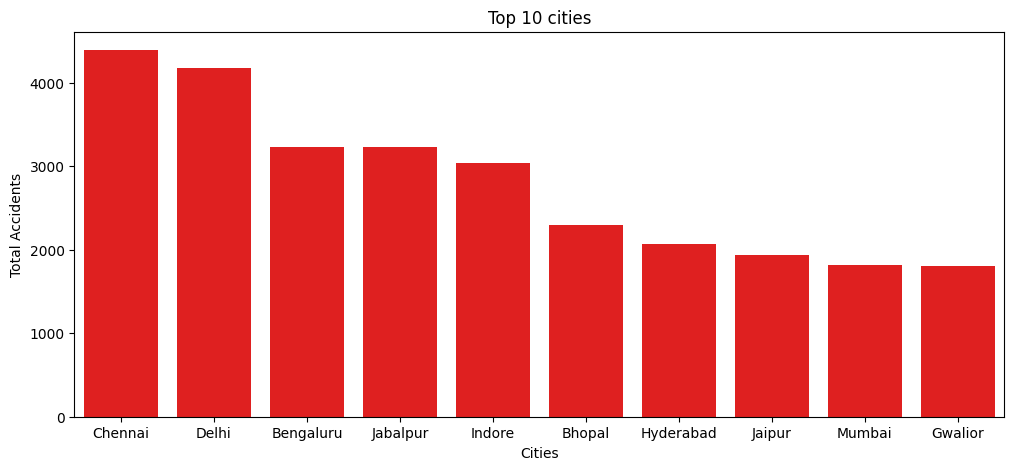

In [16]:
# Plotting the above

top_10 = accidents_city[:10]
plt.figure(figsize = (12,5))
sns.barplot(x = 'City_Name', y = 'Total_Accidents',data = top_10,color = 'red')
plt.title('Top 10 cities')
plt.xlabel('Cities')
plt.ylabel('Total Accidents')
plt.show()

* Chennai has the most accidents (4,389), followed by Delhi (4,178) and Bengaluru (3,233).

In [17]:
# Querying for top 5 cities with the highest "Persons Killed"

person_killed = one_category[one_category['Outcome_of_Incident'] == 'Persons Killed'].groupby('City_Name')\
                            .agg(Total_Persons_Killed = ('Count_in_mil','sum')).sort_values(by = 'Total_Persons_Killed',ascending = False)
person_killed

,Total_Persons_Killed
City_Name,
Delhi,1196.0
Chennai,872.0
Bengaluru,646.0
Jaipur,606.0
Kanpur,563.0
Allahabad(Prayagraj),517.0
Agra,514.0
Raipur,482.0
Indore,459.0


* Delhi has the most deaths (1,196), followed by Chennai (872) and Bengaluru (646).
* Srinagar has the fewest deaths (45), then Jamshedpur (47).

In [18]:
# Querying for the leading cause inside each Cause_Category (its share of that category's accidents)
# Categories can't be compared with each other, because each one splits the same accidents.

cause_share = accidents_only.groupby(['Cause_Category','Cause_Subcategory'])['Count_in_mil'].sum()
cause_share = (cause_share / cause_share.groupby(level = 0).transform('sum') * 100).round(1)
cause_share.sort_values(ascending = False).groupby(level = 0).head(1)

Cause_Category            Cause_Subcategory
Weather                   Sunny/Clear          72.8
Traffic Violation         Over                 70.7
Road Features             Straight Road        60.6
Junction                  Others               55.5
Traffic Control           Others               55.4
Impacting Vehicle/Object  Two Wheelers         42.6
Name: Count_in_mil, dtype: float64

* Inside each category: over-speeding ('Over' in the data) accounts for 70.7% of accidents among traffic violations, straight roads for 60.6% among road features, and two-wheelers for 42.6% among impacting vehicles. 72.8% of accidents happened in sunny or clear weather.
* Averages can't rank the categories against each other: a category with fewer subcategories simply has bigger rows.

In [19]:
# Sorting causes by number of deaths

deaths = road_accident_df[road_accident_df['Outcome_of_Incident'] == 'Persons Killed'].groupby('Cause_Category')\
            .agg(Total_Deaths = ('Count_in_mil','sum')).sort_values(by = 'Total_Deaths',ascending = False)
deaths

,Total_Deaths
Cause_Category,
Impacting Vehicle/Object,13542.0
Junction,13542.0
Road Features,13542.0
Traffic Control,13542.0
Traffic Violation,13542.0
Weather,13542.0


* Every category adds up to the same 13,542 deaths. This confirms that the categories are different breakdowns of the same deaths, not competing causes.

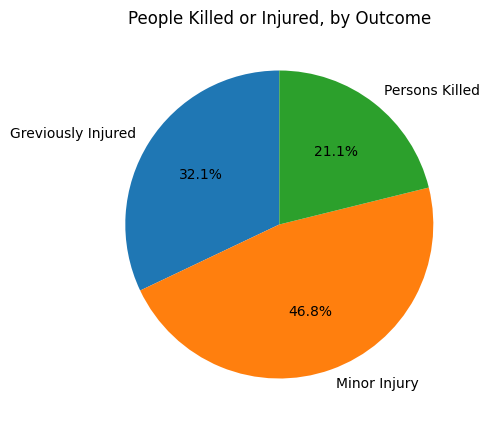

In [20]:
# Querying people killed or injured by Outcome of Incident and plotting it
# 'Total number of Accidents' counts accidents, not people, and 'Total Injured' repeats the two injury rows, so both are left out.

people = one_category[one_category['Outcome_of_Incident'].isin(['Persons Killed','Greviously Injured','Minor Injury'])]
outcome_people = people.groupby('Outcome_of_Incident').agg(Total_People = ('Count_in_mil','sum'))

# Plotting in pie chart

plt.figure(figsize = (10,5))
plt.pie(outcome_people['Total_People'],labels=outcome_people.index,autopct='%1.1f%%',startangle=90)
plt.title("People Killed or Injured, by Outcome")
plt.show()

* Of the 64,057 people killed or injured, 21.1% died, 32.1% were grievously injured and 46.8% had minor injuries.

In [21]:
# Calculating fatality ratio: deaths per accident in each city

total_accidents = one_category[one_category['Outcome_of_Incident'] == 'Total number of Accidents']\
                    .groupby('City_Name').agg(Total_Accidents = ('Count_in_mil','sum'))

fatal_accident = one_category[one_category['Outcome_of_Incident'] == 'Persons Killed']\
                    .groupby('City_Name').agg(Persons_killed = ('Count_in_mil','sum'))

fatality_ratio = (fatal_accident['Persons_killed']/total_accidents['Total_Accidents']).reset_index(name = 'Fatality_Ratio')\
                    .sort_values(by = 'Fatality_Ratio',ascending = False)

fatality_ratio.round(2)

,City_Name,Fatality_Ratio
4,Asansol Durgapur,0.74
30,Ludhiana,0.68
3,Amritsar,0.66
0,Agra,0.57
12,Dhanbad,0.51
21,Jodhpur,0.49
37,Patna,0.49
33,Meerut,0.48
47,Varanasi,0.48
14,Ghaziabad,0.46


* Asansol Durgapur has the highest fatality ratio: 0.74 deaths per accident, against 0.23 overall. Ludhiana (0.68) and Amritsar (0.66) follow.
* Kochi has the lowest fatality ratio (0.07).

### Analysis

* The 6 cause categories are 6 breakdowns of the same accidents, so every total here is computed inside one category. Adding up all rows had counted each accident 6 times (Chennai showed 78,459 accidents instead of 4,389).
* The 50 cities recorded 58,736 accidents and 13,542 deaths: about 23 deaths per 100 accidents.
* Chennai has the most accidents (4,389), but Delhi has the most deaths (1,196).
* Asansol Durgapur has the highest fatality ratio (0.74 deaths per accident), more than three times the overall rate; Kochi has the lowest (0.07).
* Over-speeding accounts for 66.5% of deaths and 70.7% of accidents among traffic violations.
* Two-wheelers are involved in 42.6% of accidents when broken down by impacting vehicle.